# Housing Price Index Forecasting — New Housing in Catalonia

**Ivan Betriu Kahlenberg · Marc Fort Garcia** — MSc in Data Science, La Salle (URL), 2025

Quarterly IPV series from INE (2007Q1–2024Q4). Models compared: Holt linear, ARIMA, ETS and XGBoost.
Results and discussion: see the [project README](../README.md).


In [ ]:
if (!requireNamespace("tseries", quietly = TRUE)) {
  install.packages("tseries")
}
if (!requireNamespace("forecast", quietly = TRUE)) {
  install.packages("forecast")
}

if (!requireNamespace("xgboost", quietly = TRUE)) {
  install.packages("xgboost")
}
if (!requireNamespace("data.table", quietly = TRUE)) {
  install.packages("data.table")
}
if (!requireNamespace("Metrics", quietly = TRUE)) {
  install.packages("Metrics")
}

library(forecast)
library(tseries)
library(xgboost)
library(data.table)
library(Metrics)
library(ggplot2)

In [ ]:
# Leer como Latin1 (ISO-8859-1)
df <- read.csv2("../data/vivienda.csv",
                header = TRUE,
                fileEncoding = "ISO-8859-1")

In [ ]:
head(df)

,Total.Nacional,Comunidades.y.Ciudades.Autónomas,General..vivienda.nueva.y.de.segunda.mano,Índices.y.tasas,Periodo,Total
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,Nacional,09 Cataluña,Vivienda nueva,Índice,2024T4,199.354
2,Nacional,09 Cataluña,Vivienda nueva,Índice,2024T3,200.203
3,Nacional,09 Cataluña,Vivienda nueva,Índice,2024T2,193.624
4,Nacional,09 Cataluña,Vivienda nueva,Índice,2024T1,190.301
5,Nacional,09 Cataluña,Vivienda nueva,Índice,2023T4,181.233
6,Nacional,09 Cataluña,Vivienda nueva,Índice,2023T3,182.398


In [ ]:
# Se selecciona la columna de la serie temporal
st = df[,6]
st = rev(st)
st

[1] 141.831 147.894 148.170 147.761 148.072 149.895 147.560 145.389 135.874
[10] 134.897 130.840 130.266 128.440 129.058 127.451 127.204 125.605 121.621
[19] 117.938 110.235 103.048 101.683  97.878  97.521  89.603  86.286  91.229
[28]  92.372  91.715  93.777  96.154  94.599  96.498  98.605 102.077 102.820
[37] 104.474 108.531 110.368 108.294 112.595 116.976 119.680 119.185 121.523
[46] 127.252 128.878 131.023 135.929 133.465 137.372 137.426 145.680 143.046
[55] 150.374 151.748 149.613 152.409 153.136 158.624 162.982 163.891 165.509
[64] 167.994 174.425 176.747 182.398 181.233 190.301 193.624 200.203 199.354

In [ ]:
# Invertimos orden para empezar con el registro más antiguo
df_extramuestral <- tail(st, 14)
df_extramuestral

[1] 153.136 158.624 162.982 163.891 165.509 167.994 174.425 176.747 182.398
[10] 181.233 190.301 193.624 200.203 199.354

In [ ]:
# Nº de datos
length(df_extramuestral)

[1] 14

In [ ]:
df_muestral <- head(st, 58)


	Augmented Dickey-Fuller Test

data:  df_muestral
Dickey-Fuller = -1.1109, Lag order = 3, p-value = 0.913
alternative hypothesis: stationary


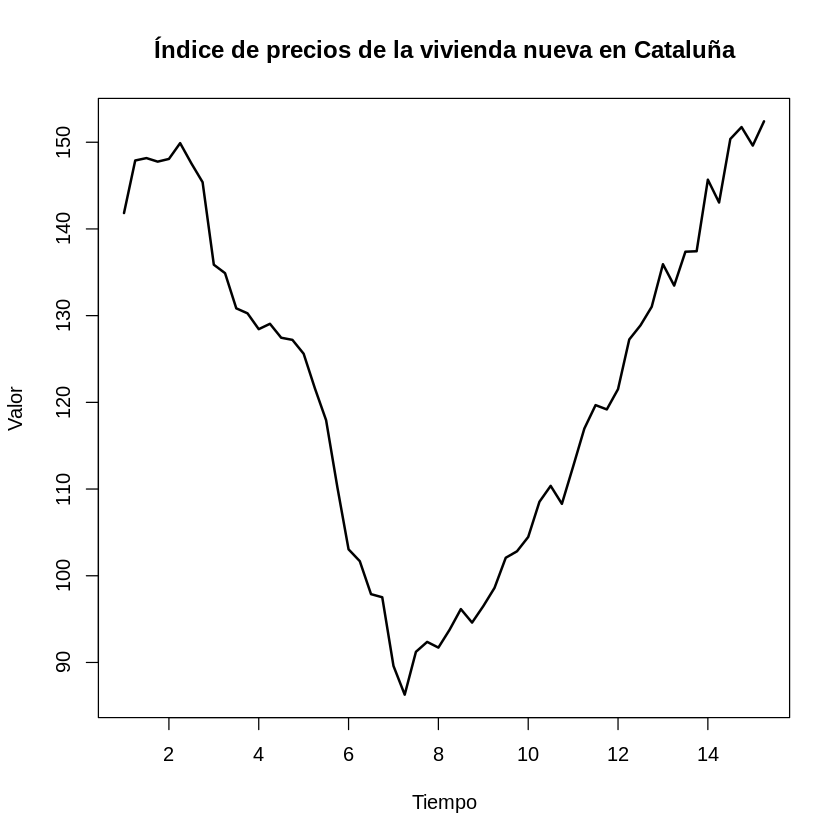

In [ ]:
# Visualización serie
serie_ts <- ts(df_muestral, start = 1, frequency = 4)
plot(
  serie_ts,
  type  = "l",
  lwd   = 2,
  xlab  = "Tiempo",
  ylab  = "Valor",
  main  = "Índice de precios de la vivienda nueva en Cataluña"
)


# Test ADF en la serie original
adf_orig <- adf.test(df_muestral)

# Mostrar resultados
adf_orig


Se aprecia que de base la serie no cuenta con estacionariedad dado que el p_value se ubica por encima del 0.05.

# SUAVIZADO HOLT (tendencia sin estacionariedad)

MSE:  215.7156 
RMSE: 14.6873 
MAE:  12.1933 


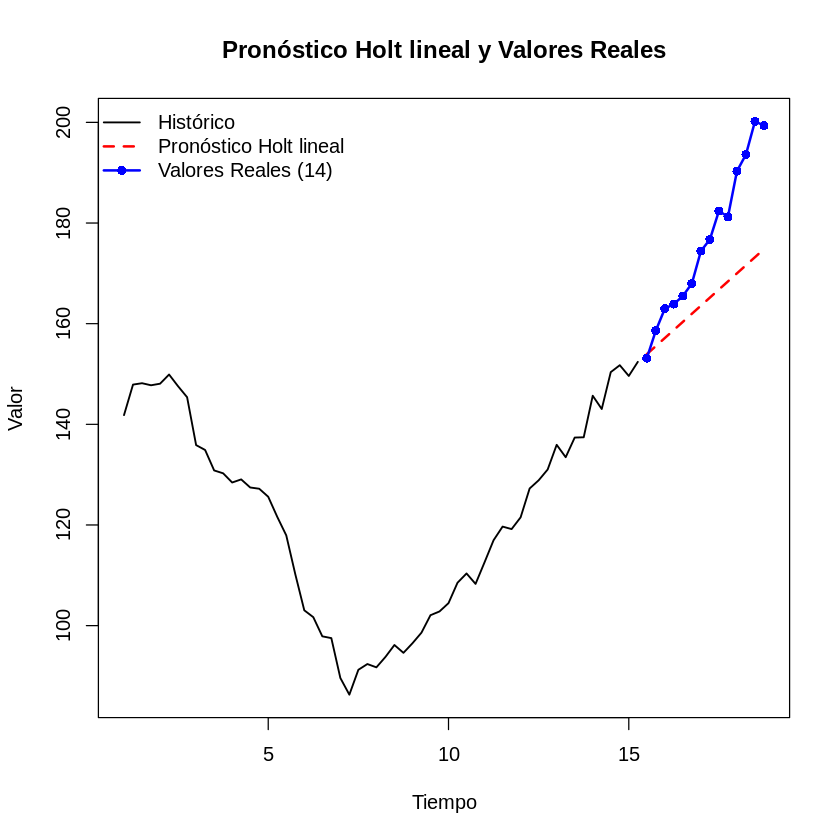

In [ ]:
# 1. Ajustar Holt lineal (nivel + pendiente) a la serie histórica completa y proyectar 14 períodos
library(forecast)
fit_holt_linear <- holt(serie_ts, h = 14)
ts_forecast <- fit_holt_linear$mean  # objeto 'ts' de longitud 14

# 2. Extraer las 14 observaciones reales de df_extramuestral (vector numérico)
reales_14 <- tail(df_extramuestral, 14)

# 3. Convertir esos 14 valores reales en un objeto 'ts', alineado con ts_forecast
start_forecast <- start(ts_forecast)
freq <- frequency(ts_forecast)
ts_reales <- ts(reales_14,
                start     = start_forecast,
                frequency = freq)

# 4. Calcular métricas de error: MSE, RMSE y MAE
predicted_vec <- as.numeric(ts_forecast)
actual_vec    <- as.numeric(ts_reales)
errors        <- predicted_vec - actual_vec
abs_errors    <- abs(errors)

MSE  <- mean(errors^2, na.rm = TRUE)
RMSE <- sqrt(MSE)
MAE  <- mean(abs_errors, na.rm = TRUE)

cat("MSE: ",  round(MSE,  4), "\n")
cat("RMSE:",  round(RMSE, 4), "\n")
cat("MAE: ",  round(MAE,  4), "\n")

# 5. Determinar límites para los ejes combinando histórico, pronóstico y reales
x_min <- start(serie_ts)[1] + (start(serie_ts)[2] - 1) / frequency(serie_ts)
x_max <- end(ts_forecast)[1] + (end(ts_forecast)[2] - 1) / frequency(ts_forecast)

y_min <- min(c(as.numeric(serie_ts), predicted_vec, actual_vec), na.rm = TRUE)
y_max <- max(c(as.numeric(serie_ts), predicted_vec, actual_vec), na.rm = TRUE)

# 6. Graficar la serie histórica completa en negro
plot(serie_ts,
     xlim = c(x_min, x_max),
     ylim = c(y_min, y_max),
     col  = "black",
     lwd  = 1.5,
     ylab = "Valor",
     xlab = "Tiempo",
     main = "Pronóstico Holt lineal y Valores Reales")

# 7. Superponer la línea de pronóstico (14 períodos), color 'red', línea punteada
lines(ts_forecast, col = "red", lty = 2, lwd = 2)

# 8. Superponer los valores reales de esos 14 períodos (línea y puntos), color 'blue'
lines(ts_reales, col = "blue", lty = 1, lwd = 2)
points(ts_reales, col = "blue", pch = 16)

# 9. Añadir leyenda
legend("topleft",
       legend = c("Histórico", "Pronóstico Holt lineal", "Valores Reales (14)"),
       col    = c("black", "red", "blue"),
       lty    = c(1, 2, 1),
       lwd    = c(1.5, 2, 2),
       pch    = c(NA, NA, 16),
       bty    = "n")


Decomposició clasica:
-Tendencia (trend)
-Estacionalidad (seasonal)
-Residuo (remainder)

ACF y PACF
Estacionalidad

  1. Métodos Deterministas

  1.1. Proyección de Tendencia Lineal (Regresión Simple sobre el Tiempo)

  1.2. Descomposición Clásica (Tendencia + Estacionalidad + Residuo)

  1.3. Suavizado Exponencial Simple o Doble

2. Métodos Estocásticos
2.1. Modelos ARIMA (o SARIMA para estacionalidad)
2.2. Modelos ETS (Suavizado Exponencial en forma de espacio-estado)


  3. Métodos de Machine Learning (ML)

  3.1. Regresión con Variables de Rezago (Lagged Features + Random Forest / XGBoost)

  3.2. Redes Neuronales (MLP o LSTM)

In [ ]:
# Ajustar ARIMA automático (incluye SARIMA si detecta estacionalidad)
fit_arima <- auto.arima(serie_ts)

# Resumen del modelo
summary(fit_arima)

# Pronóstico para 14 períodos futuros
fcast_arima <- forecast(fit_arima, h = 14)

# Graficar pronóstico
plot(fcast_arima)

In [ ]:
# Valores pronosticados (mean forecast)
preds_arima <- as.numeric(fcast_arima$mean)


real_values <- as.numeric(df_extramuestral)

In [ ]:
rmse_val <- rmse(real_values, preds_arima)
mae_val <- mae(real_values, preds_arima)
mse_val <- mse(real_values, preds_arima)

print(paste("RMSE:", rmse_val))
print(paste("MAE:", mae_val))
print(paste("MSE:", mse_val))

In [ ]:
# Valores históricos (serie_ts)
historical <- as.numeric(serie_ts)

# Valores reales futuros (extramuestral)
real_values <- as.numeric(df_extramuestral)

# Valores pronosticados futuros
preds_arima <- as.numeric(fcast_arima$mean)

# Crear vector de tiempos para el histórico y futuro
# Asumiendo que la frecuencia es trimestral, frequency = 4
start_time <- start(serie_ts)  # ej: c(año, trimestre)
freq <- frequency(serie_ts)

# Crear secuencia de tiempo para histórico
time_historical <- seq(from = start_time[1] + (start_time[2] - 1)/freq,
                       length.out = length(historical), by = 1/freq)

# Crear secuencia de tiempo para futuro
time_future <- seq(from = tail(time_historical, 1) + 1/freq, length.out = length(real_values), by = 1/freq)

# Data frame con todo junto
df_plot <- data.frame(
  Time = c(time_historical, time_future, time_future),
  Value = c(historical, real_values, preds_arima),
  Type = factor(c(
    rep("Histórico", length(historical)),
    rep("Real futuro", length(real_values)),
    rep("Pronóstico", length(preds_arima))
  ), levels = c("Histórico", "Real futuro", "Pronóstico"))
)

# Graficar
ggplot(df_plot, aes(x = Time, y = Value, color = Type)) +
  geom_line(size = 1) +
  labs(
    title = "Serie histórica y comparación de pronóstico ARIMA vs valores reales futuros",
    x = "Tiempo (años)",
    y = "Valor"
  ) +
  scale_color_manual(values = c(
    "Histórico" = "black",
    "Real futuro" = "blue",
    "Pronóstico" = "red"
  )) +
  theme_minimal()


In [ ]:
# Ajustar modelo ETS
fit_ets <- ets(serie_ts)

# Resumen
summary(fit_ets)

# Pronóstico
fcast_ets <- forecast(fit_ets, h = 14)

# Graficar
plot(fcast_ets)

In [ ]:
# Valors històrics de la sèrie (vector numèric)
historical <- as.numeric(serie_ts)

# Valors reals extramuestrals
real_values <- as.numeric(df_extramuestral)

# Valors pronosticats ETS
preds_ets <- as.numeric(fcast_ets$mean)

# Seqüència de temps per històrics i futurs (freq = 4 per quarters)
start_time <- start(serie_ts)
freq <- frequency(serie_ts)

time_historical <- seq(from = start_time[1] + (start_time[2] - 1)/freq,
                       length.out = length(historical), by = 1/freq)

time_future <- seq(from = tail(time_historical, 1) + 1/freq, length.out = length(real_values), by = 1/freq)

# Crear dataframe per graficar
df_plot <- data.frame(
  Time = c(time_historical, time_future, time_future),
  Value = c(historical, real_values, preds_ets),
  Type = factor(c(
    rep("Històric", length(historical)),
    rep("Real futur", length(real_values)),
    rep("Pronòstic ETS", length(preds_ets))
  ), levels = c("Històric", "Real futur", "Pronòstic ETS"))
)

# Calcular errors
mse_val <- mse(real_values, preds_ets)
rmse_val <- rmse(real_values, preds_ets)
mae_val <- mae(real_values, preds_ets)

print(paste("MSE ETS:", mse_val))
print(paste("RMSE ETS:", rmse_val))
print(paste("MAE ETS:", mae_val))

# Graficar
ggplot(df_plot, aes(x = Time, y = Value, color = Type)) +
  geom_line(size = 1) +
  labs(
    title = "Sèrie històrica i comparació pronòstic ETS vs valors reals futurs",
    x = "Temps (anys)",
    y = "Valor"
  ) +
  scale_color_manual(values = c(
    "Històric" = "black",
    "Real futur" = "blue",
    "Pronòstic ETS" = "red"
  )) +
  theme_minimal()

In [ ]:
# Crear función para matriz de lags
create_lagged_matrix <- function(series, n_lags) {
  n <- length(serie_ts)
  data <- embed(serie_ts, n_lags + 1)
  # La columna 1 es y_t, las siguientes son lags (y_{t-1}, y_{t-2}, ...)
  y <- data[,1]
  X <- data[,-1]
  list(X = X, y = y)
}
# Número de lags a usar como predictores
n_lags <- 4
train_series <- serie_ts
lagged_data <- create_lagged_matrix(train_series, n_lags)
X_train <- lagged_data$X
y_train <- lagged_data$y

# Convertir a formato xgb.DMatrix
dtrain <- xgb.DMatrix(data = X_train, label = y_train)

In [ ]:
params <- list(
  objective = "reg:squarederror",
  eval_metric = "rmse"
)

model <- xgb.train(
  params = params,
  data = dtrain,
  nrounds = 100,
  verbose = 0
)

In [ ]:
# Valores reales extramuestrales
extramuestral <- as.numeric(df_extramuestral)  # vector con 14 valores reales

# Para predecir, usamos un "rolling forecast" (predicción recursiva)
preds <- numeric(14)

# Últimos lags disponibles para empezar (los últimos 4 valores de train)
last_values <- tail(train_series, n_lags)

for (i in 1:14) {
  # Crear matriz de input para predecir un solo valor
  input <- matrix(last_values, nrow = 1)
  colnames(input) <- NULL

  # Predecir
  pred <- predict(model, input)
  preds[i] <- pred

  # Actualizar last_values desplazando y agregando predicción
  last_values <- c(pred, last_values[1:(n_lags - 1)])
}

In [ ]:
# Valores históricos (vector numérico)
historical <- as.numeric(serie_ts)

# Valores reales extramuestrales (14)
real_values <- extramuestral

# Valores pronosticados con XGBoost (14)
preds_xgb <- preds

# Validar que longitudes coincidan
if(length(real_values) != length(preds_xgb)) {
  stop("La longitud de valores reales y predichos no coincide.")
}

# Crear secuencia de tiempo para histórico y futuro
start_time <- start(serie_ts)
freq <- frequency(serie_ts)

time_historical <- seq(from = start_time[1] + (start_time[2] - 1)/freq,
                       length.out = length(historical), by = 1/freq)

time_future <- seq(from = tail(time_historical, 1) + 1/freq, length.out = length(real_values), by = 1/freq)

# Crear dataframe para graficar
df_plot <- data.frame(
  Time = c(time_historical, time_future, time_future),
  Value = c(historical, real_values, preds_xgb),
  Type = factor(c(
    rep("Histórico", length(historical)),
    rep("Real futuro", length(real_values)),
    rep("Pronóstico XGBoost", length(preds_xgb))
  ), levels = c("Histórico", "Real futuro", "Pronóstico XGBoost"))
)

# Calcular errores
mse_val <- mse(real_values, preds_xgb)
rmse_val <- rmse(real_values, preds_xgb)
mae_val <- mae(real_values, preds_xgb)

print(paste("MSE XGBoost:", mse_val))
print(paste("RMSE XGBoost:", rmse_val))
print(paste("MAE XGBoost:", mae_val))

# Graficar
ggplot(df_plot, aes(x = Time, y = Value, color = Type)) +
  geom_line(size = 1) +
  labs(
    title = "Serie histórica y comparación pronóstico XGBoost vs valores reales futuros",
    x = "Tiempo (años)",
    y = "Valor"
  ) +
  scale_color_manual(values = c(
    "Histórico" = "black",
    "Real futuro" = "blue",
    "Pronóstico XGBoost" = "red"
  )) +
  theme_minimal()
